In [3]:
import pickle
import numpy as np
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, find_peaks, welch
from scipy.stats import skew, kurtosis
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 
            'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

DATA_DIR = Path('model/wesad')
WINDOW_SIZE_SEC = 45
FS = 700

EMOTION_NAMES_4CLASS = {0: 'Baseline', 1: 'Stress', 2: 'Amusement', 3: 'Meditation'}
EMOTION_NAMES_BINARY = {0: 'Non-Stress', 1: 'Stress'}
EMOTION_NAMES = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}

def extract_extended_hrv_features(ecg_segment, fs=700):
    if len(ecg_segment) < int(fs * 10):
        return None
    
    sos = butter(2, [5, 15], btype='band', fs=fs, output='sos')
    ecg_band = sosfiltfilt(sos, ecg_segment)
    ecg_squared = ecg_band ** 2
    window_size = int(0.15 * fs)
    ecg_integrated = np.convolve(ecg_squared, np.ones(window_size)/window_size, mode='same')
    
    threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
    r_peaks, _ = find_peaks(ecg_integrated, height=threshold, distance=int(0.4 * fs))
    
    if len(r_peaks) < 10:
        return None
    
    rr_samples = np.diff(r_peaks)
    rr_ms = (rr_samples / fs) * 1000
    
    rr_ms = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_ms) < 8:
        return None
    
    nn_diffs = np.diff(rr_ms)
    
    mean_rr = np.mean(rr_ms)
    sdnn = np.std(rr_ms, ddof=1)
    rmssd = np.sqrt(np.mean(nn_diffs ** 2))
    nn50 = np.sum(np.abs(nn_diffs) > 50)
    pnn50 = (nn50 / len(nn_diffs)) * 100 if len(nn_diffs) > 0 else 0
    nn20 = np.sum(np.abs(nn_diffs) > 20)
    pnn20 = (nn20 / len(nn_diffs)) * 100 if len(nn_diffs) > 0 else 0
    mean_hr = 60000 / mean_rr
    sdsd = np.std(nn_diffs, ddof=1) if len(nn_diffs) > 1 else 0
    cvnn = (sdnn / mean_rr) * 100 if mean_rr > 0 else 0
    cvsd = (rmssd / mean_rr) * 100 if mean_rr > 0 else 0
    median_rr = np.median(rr_ms)
    mad_rr = np.median(np.abs(rr_ms - median_rr))
    rr_range = np.max(rr_ms) - np.min(rr_ms)
    rr_iqr = np.percentile(rr_ms, 75) - np.percentile(rr_ms, 25)
    hr_max = 60000 / np.min(rr_ms)
    hr_min = 60000 / np.max(rr_ms)
    hr_range = hr_max - hr_min
    
    rr_skew = skew(rr_ms)
    rr_kurt = kurtosis(rr_ms)
    
    try:
        rr_times = np.cumsum(rr_ms) / 1000.0
        rr_times = rr_times - rr_times[0]
        
        if len(rr_times) > 4 and rr_times[-1] > 0:
            fs_interp = 4.0
            t_interp = np.arange(0, rr_times[-1], 1.0/fs_interp)
            
            if len(t_interp) > 16:
                interp_func = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')
                rr_interp = interp_func(t_interp)
                
                freqs, psd = welch(rr_interp, fs=fs_interp, nperseg=min(len(rr_interp), 64))
                
                vlf_mask = (freqs >= 0.003) & (freqs < 0.04)
                lf_mask = (freqs >= 0.04) & (freqs < 0.15)
                hf_mask = (freqs >= 0.15) & (freqs < 0.4)
                
                vlf_power = np.trapz(psd[vlf_mask], freqs[vlf_mask]) if np.any(vlf_mask) else 0
                lf_power = np.trapz(psd[lf_mask], freqs[lf_mask]) if np.any(lf_mask) else 0
                hf_power = np.trapz(psd[hf_mask], freqs[hf_mask]) if np.any(hf_mask) else 0
                
                total_power = vlf_power + lf_power + hf_power
                lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
                lf_norm = (lf_power / (lf_power + hf_power)) * 100 if (lf_power + hf_power) > 0 else 0
                hf_norm = (hf_power / (lf_power + hf_power)) * 100 if (lf_power + hf_power) > 0 else 0
            else:
                vlf_power = lf_power = hf_power = total_power = 0
                lf_hf_ratio = lf_norm = hf_norm = 0
        else:
            vlf_power = lf_power = hf_power = total_power = 0
            lf_hf_ratio = lf_norm = hf_norm = 0
    except:
        vlf_power = lf_power = hf_power = total_power = 0
        lf_hf_ratio = lf_norm = hf_norm = 0
    
    sd1 = np.sqrt(0.5 * np.var(nn_diffs)) if len(nn_diffs) > 1 else 0
    sd2 = np.sqrt(2 * np.var(rr_ms) - 0.5 * np.var(nn_diffs)) if len(nn_diffs) > 1 else 0
    sd1_sd2_ratio = sd1 / sd2 if sd2 > 0 else 0
    
    features = [
        mean_rr, sdnn, rmssd, nn50, pnn50, nn20, pnn20,
        mean_hr, sdsd, cvnn, cvsd,
        median_rr, mad_rr, rr_range, rr_iqr,
        hr_max, hr_min, hr_range,
        rr_skew, rr_kurt,
        vlf_power, lf_power, hf_power, total_power,
        lf_hf_ratio, lf_norm, hf_norm,
        sd1, sd2, sd1_sd2_ratio
    ]
    
    return features

FEATURE_NAMES = [
    'mean_rr', 'sdnn', 'rmssd', 'nn50', 'pnn50', 'nn20', 'pnn20',
    'mean_hr', 'sdsd', 'cvnn', 'cvsd',
    'median_rr', 'mad_rr', 'rr_range', 'rr_iqr',
    'hr_max', 'hr_min', 'hr_range',
    'rr_skew', 'rr_kurt',
    'vlf_power', 'lf_power', 'hf_power', 'total_power',
    'lf_hf_ratio', 'lf_norm', 'hf_norm',
    'sd1', 'sd2', 'sd1_sd2_ratio'
]

def load_subject_extended(subject_id='S2', window_size_sec=WINDOW_SIZE_SEC, fs=FS):
    data_path = DATA_DIR / subject_id / f'{subject_id}.pkl'
    
    if not data_path.exists():
        print(f"File not found: {data_path}")
        return None, None
    
    with open(data_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    ecg_raw = data['signal']['chest']['ECG'].flatten()
    labels = data['label'].flatten()
    
    sos = butter(4, [0.5, 100], btype='band', fs=fs, output='sos')
    ecg_filtered = sosfiltfilt(sos, ecg_raw)
    
    window_samples = fs * window_size_sec
    step_samples = window_samples // 3
    
    X = []
    y = []
    
    for i in range(0, len(ecg_filtered) - window_samples, step_samples):
        ecg_window = ecg_filtered[i:i+window_samples]
        label_window = labels[i:i+window_samples]
        
        unique, counts = np.unique(label_window.astype(int), return_counts=True)
        main_label = unique[np.argmax(counts)]
        label_purity = counts.max() / counts.sum()
        
        if main_label == 0 or label_purity < 0.95:
            continue
        
        hrv_features = extract_extended_hrv_features(ecg_window, fs)
        
        if hrv_features is None:
            continue
        
        X.append(hrv_features)
        y.append(main_label)
    
    X = np.array(X) if X else None
    y = np.array(y) if y else None
    
    return X, y

print("=" * 80)
print("LOADING DATA WITH EXTENDED HRV FEATURES (30 features)")
print("=" * 80 + "\n")

all_X = []
all_y = []
subject_ids = []

for subject in SUBJECTS:
    X, y = load_subject_extended(subject)
    
    if X is not None and len(X) > 0:
        all_X.append(X)
        all_y.append(y)
        subject_ids.extend([subject] * len(X))
        print(f"{subject}: {len(X)} windows")

X_all = np.vstack(all_X)
y_all = np.hstack(all_y)
subject_ids = np.array(subject_ids)

print("\n" + "=" * 80)
print("TOTAL:")
print("=" * 80)
print(f"Total windows: {len(X_all)}")
print(f"X_all.shape: {X_all.shape} ({len(FEATURE_NAMES)} HRV features)")

print(f"\nClass distribution:")
for emotion_id in [1, 2, 3, 4]:
    count = np.sum(y_all == emotion_id)
    pct = 100 * count / len(y_all)
    print(f"{EMOTION_NAMES[emotion_id]:15s} {count:3d} ({pct:5.1f}%)")


LOADING DATA WITH EXTENDED HRV FEATURES (30 features)

S2: 180 windows
S3: 188 windows
S4: 186 windows
S5: 190 windows
S6: 189 windows
S7: 185 windows
S8: 189 windows
S9: 191 windows
S10: 194 windows
S11: 189 windows
S13: 189 windows
S14: 192 windows
S15: 188 windows
S16: 190 windows
S17: 194 windows

TOTAL:
Total windows: 2834
X_all.shape: (2834, 30) (30 HRV features)

Class distribution:
Baseline        1133 ( 40.0%)
Stress          624 ( 22.0%)
Amusement       330 ( 11.6%)
Meditation      703 ( 24.8%)


In [4]:
X_all = np.nan_to_num(X_all, nan=0, posinf=0, neginf=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print("=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

print(f"\nFeatures normalized: {X_scaled.shape[1]} features")
print(f"Samples: {X_scaled.shape[0]}")

print(f"\nKey feature statistics by class:")
key_features = ['mean_hr', 'sdnn', 'rmssd', 'lf_hf_ratio', 'pnn50']
key_indices = [FEATURE_NAMES.index(f) for f in key_features]

for emotion_id in [1, 2, 3, 4]:
    mask = y_all == emotion_id
    if np.sum(mask) > 0:
        features = X_all[mask]
        print(f"\n{EMOTION_NAMES[emotion_id]}:")
        for fname, fidx in zip(key_features, key_indices):
            print(f"  {fname:12s} Mean: {features[:, fidx].mean():8.2f}, Std: {features[:, fidx].std():8.2f}")


DATA PREPROCESSING

Features normalized: 30 features
Samples: 2834

Key feature statistics by class:

Baseline:
  mean_hr      Mean:    72.33, Std:    11.03
  sdnn         Mean:    68.35, Std:    28.52
  rmssd        Mean:    53.92, Std:    32.81
  lf_hf_ratio  Mean:     2.06, Std:     2.18
  pnn50        Mean:    27.01, Std:    20.67

Stress:
  mean_hr      Mean:    97.05, Std:    19.09
  sdnn         Mean:    65.15, Std:    36.10
  rmssd        Mean:    51.00, Std:    47.11
  lf_hf_ratio  Mean:     3.05, Std:     4.41
  pnn50        Mean:    14.70, Std:    13.91

Amusement:
  mean_hr      Mean:    72.48, Std:    10.27
  sdnn         Mean:    74.86, Std:    32.61
  rmssd        Mean:    54.87, Std:    35.03
  lf_hf_ratio  Mean:     3.67, Std:     4.03
  pnn50        Mean:    25.26, Std:    20.82

Meditation:
  mean_hr      Mean:    68.97, Std:     8.47
  sdnn         Mean:    95.23, Std:    42.05
  rmssd        Mean:    71.70, Std:    41.60
  lf_hf_ratio  Mean:     3.69, Std:     4.31

In [5]:
print("=" * 80)
print("TRAINING TWO MODELS: 4-CLASS AND BINARY")
print("=" * 80)

valid_mask = np.isin(y_all, [1, 2, 3, 4])
X_filtered = X_scaled[valid_mask]
y_filtered = y_all[valid_mask]

print(f"\nTotal data: {len(X_filtered)} windows (classes 1-4)")

Path('model').mkdir(exist_ok=True)

print("\n" + "=" * 80)
print("MODEL 1: 4-CLASS (Baseline, Stress, Amusement, Meditation)")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.15, random_state=42, stratify=y_filtered
)

y_train_enc = y_train.astype(int) - 1
y_test_enc = y_test.astype(int) - 1

sample_weights = compute_sample_weight('balanced', y_train_enc)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

model_4class = XGBClassifier(
    n_estimators=1500, max_depth=12, learning_rate=0.02,
    min_child_weight=1, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.01, reg_lambda=0.5, gamma=0.05,
    random_state=42, n_jobs=1, verbosity=0
)
model_4class.fit(X_train, y_train_enc, sample_weight=sample_weights)

y_pred_4class = model_4class.predict(X_test)
f1_4class = f1_score(y_test_enc, y_pred_4class, average='weighted')
acc_4class = accuracy_score(y_test_enc, y_pred_4class)

print(f"\n4-Class Results:")
print(f"  F1-weighted: {f1_4class:.4f}")
print(f"  Accuracy:    {acc_4class:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_4class, target_names=['Baseline', 'Stress', 'Amusement', 'Meditation']))

pickle.dump(model_4class, open('model/model_4class.pkl', 'wb'))
print("Saved: model/model_4class.pkl")

print("\n" + "=" * 80)
print("MODEL 2: BINARY (Stress vs Non-Stress)")
print("=" * 80)

y_binary = (y_filtered == 2).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_filtered, y_binary, test_size=0.15, random_state=42, stratify=y_binary
)

sample_weights_b = compute_sample_weight('balanced', y_train_b)

print(f"Train: {len(X_train_b)}, Test: {len(X_test_b)}")
print(f"Class distribution: Non-Stress={np.sum(y_binary==0)}, Stress={np.sum(y_binary==1)}")

model_binary = XGBClassifier(
    n_estimators=1500, max_depth=10, learning_rate=0.02,
    min_child_weight=1, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.01, reg_lambda=0.5, gamma=0.05,
    scale_pos_weight=np.sum(y_binary==0)/np.sum(y_binary==1),
    random_state=42, n_jobs=1, verbosity=0
)
model_binary.fit(X_train_b, y_train_b, sample_weight=sample_weights_b)

y_pred_binary = model_binary.predict(X_test_b)
f1_binary = f1_score(y_test_b, y_pred_binary, average='weighted')
acc_binary = accuracy_score(y_test_b, y_pred_binary)

print(f"\nBinary Results:")
print(f"  F1-weighted: {f1_binary:.4f}")
print(f"  Accuracy:    {acc_binary:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_binary, target_names=['Non-Stress', 'Stress']))

pickle.dump(model_binary, open('model/model_binary.pkl', 'wb'))
print("Saved: model/model_binary.pkl")

pickle.dump(scaler, open('model/scaler.pkl', 'wb'))
pickle.dump(FEATURE_NAMES, open('model/feature_names.pkl', 'wb'))

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"4-Class Model: F1={f1_4class:.4f}, Acc={acc_4class:.4f}")
print(f"Binary Model:  F1={f1_binary:.4f}, Acc={acc_binary:.4f}")
print("\nFiles saved:")
print("  - model/model_4class.pkl")
print("  - model/model_binary.pkl")
print("  - model/scaler.pkl")
print("  - model/feature_names.pkl")

results = {
    '4class': {'f1': f1_4class, 'acc': acc_4class, 'model': model_4class, 'y_pred': y_pred_4class, 'y_test': y_test_enc},
    'binary': {'f1': f1_binary, 'acc': acc_binary, 'model': model_binary, 'y_pred': y_pred_binary, 'y_test': y_test_b}
}


TRAINING TWO MODELS: 4-CLASS AND BINARY

Total data: 2790 windows (classes 1-4)

MODEL 1: 4-CLASS (Baseline, Stress, Amusement, Meditation)
Train: 2371, Test: 419

4-Class Results:
  F1-weighted: 0.7699
  Accuracy:    0.7780

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.75      0.89      0.81       170
      Stress       0.84      0.85      0.85        94
   Amusement       0.81      0.43      0.56        49
  Meditation       0.78      0.69      0.73       106

    accuracy                           0.78       419
   macro avg       0.79      0.72      0.74       419
weighted avg       0.78      0.78      0.77       419

Saved: model/model_4class.pkl

MODEL 2: BINARY (Stress vs Non-Stress)
Train: 2371, Test: 419
Class distribution: Non-Stress=2166, Stress=624

Binary Results:
  F1-weighted: 0.9203
  Accuracy:    0.9189

Classification Report:
              precision    recall  f1-score   support

  Non-Stress       0.96      0.93  

FEATURE IMPORTANCE ANALYSIS


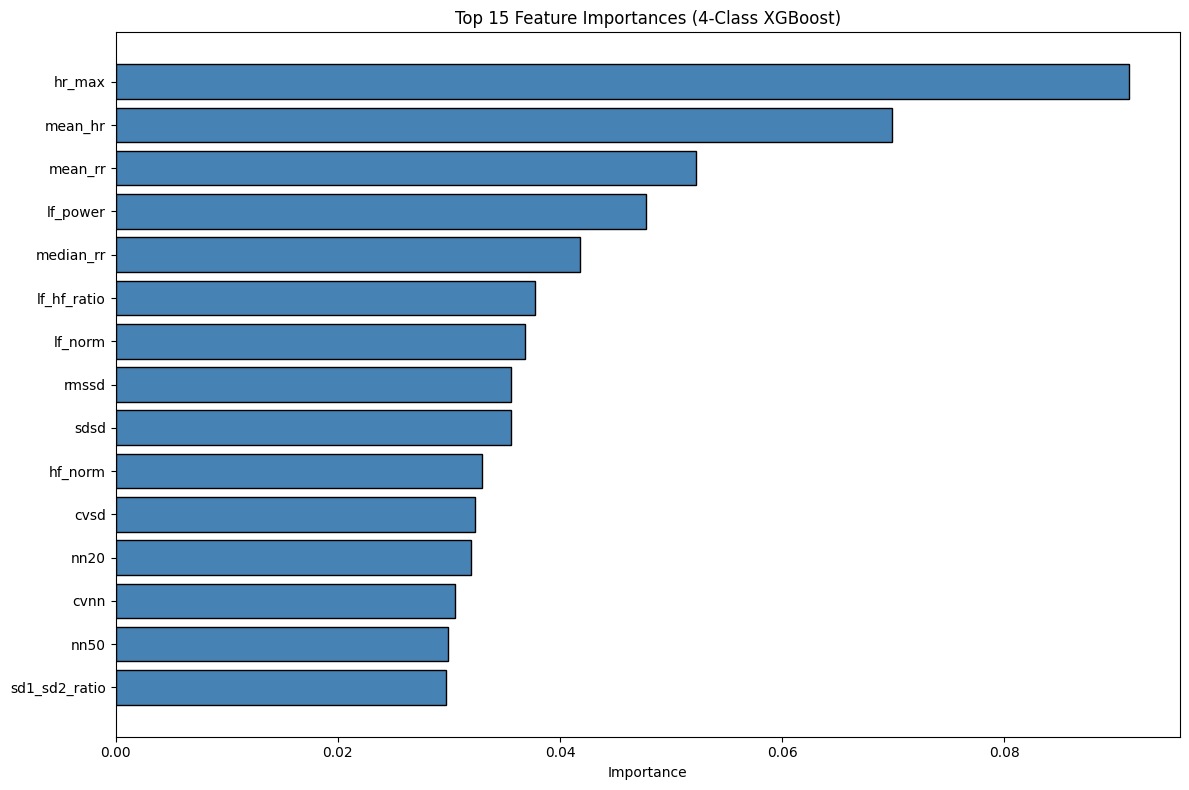


Top 10 features:
  1. hr_max               0.0912
  2. mean_hr              0.0699
  3. mean_rr              0.0522
  4. lf_power             0.0477
  5. median_rr            0.0418
  6. lf_hf_ratio          0.0377
  7. lf_norm              0.0369
  8. rmssd                0.0356
  9. sdsd                 0.0356
  10. hf_norm              0.0330


In [6]:
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

importances = model_4class.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(indices)), importances[indices][::-1], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([FEATURE_NAMES[i] for i in indices[::-1]])
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances (4-Class XGBoost)')
plt.tight_layout()
Path('outputs').mkdir(exist_ok=True)
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
for i, idx in enumerate(indices[:10]):
    print(f"  {i+1}. {FEATURE_NAMES[idx]:20s} {importances[idx]:.4f}")


CONFUSION MATRICES


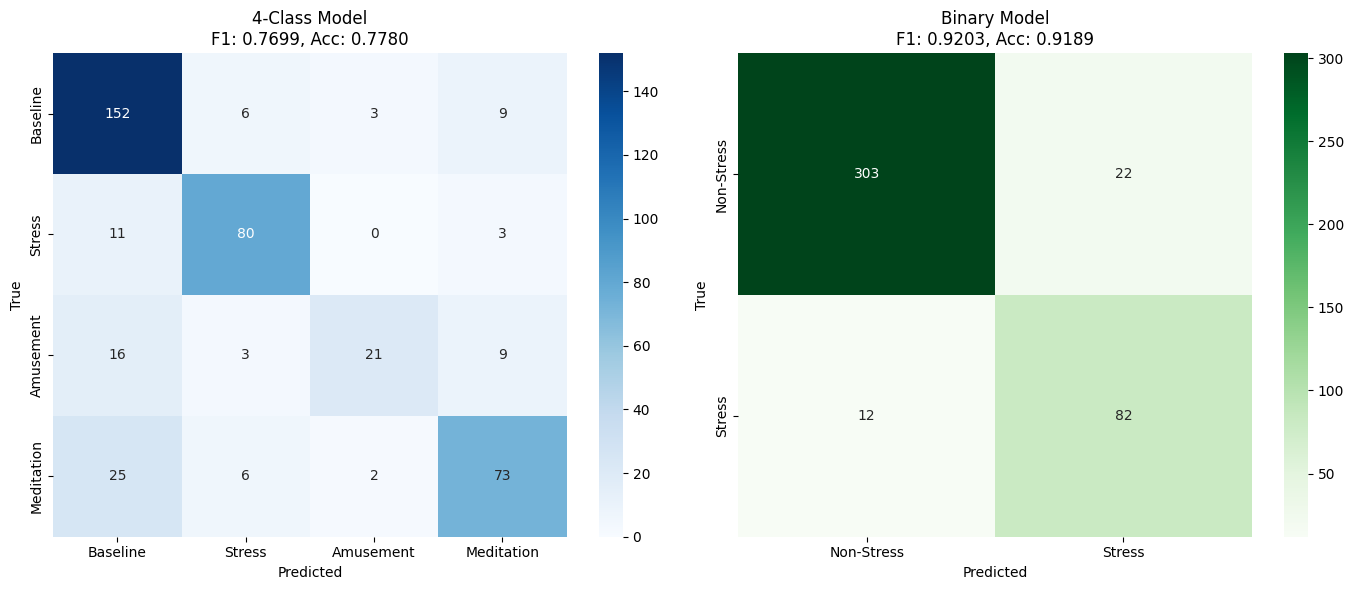

In [7]:
print("=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_4class = confusion_matrix(results['4class']['y_test'], results['4class']['y_pred'])
sns.heatmap(cm_4class, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baseline', 'Stress', 'Amusement', 'Meditation'],
            yticklabels=['Baseline', 'Stress', 'Amusement', 'Meditation'])
axes[0].set_title(f"4-Class Model\nF1: {f1_4class:.4f}, Acc: {acc_4class:.4f}")
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

cm_binary = confusion_matrix(results['binary']['y_test'], results['binary']['y_pred'])
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Non-Stress', 'Stress'],
            yticklabels=['Non-Stress', 'Stress'])
axes[1].set_title(f"Binary Model\nF1: {f1_binary:.4f}, Acc: {acc_binary:.4f}")
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


MODEL COMPARISON VISUALIZATION


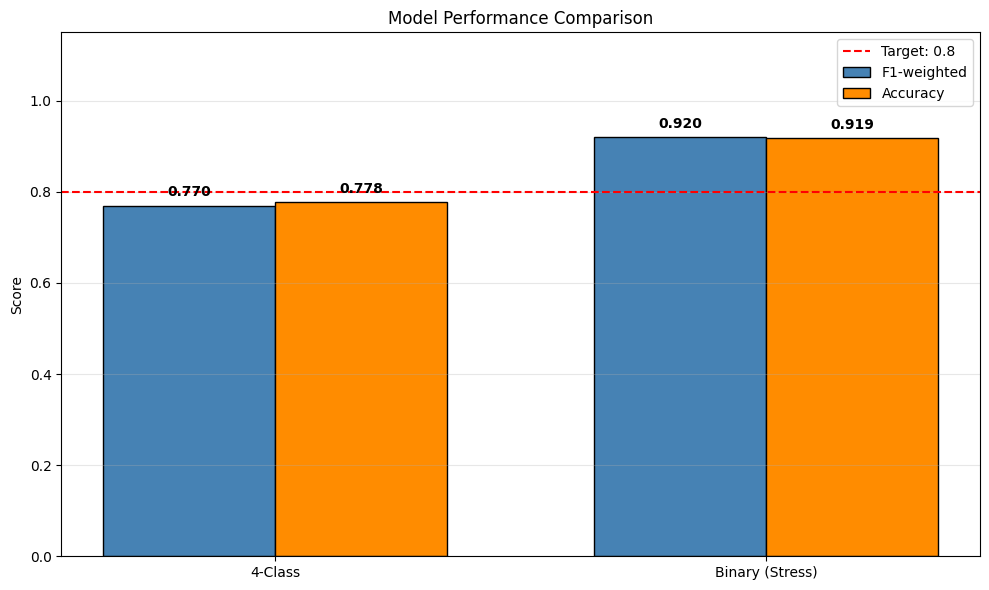

In [8]:
print("=" * 80)
print("MODEL COMPARISON VISUALIZATION")
print("=" * 80)

fig, ax = plt.subplots(figsize=(10, 6))

models = ['4-Class', 'Binary (Stress)']
f1_scores = [f1_4class, f1_binary]
acc_scores = [acc_4class, acc_binary]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-weighted', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, acc_scores, width, label='Accuracy', color='darkorange', edgecolor='black')

for bar, val in zip(bars1, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
for bar, val in zip(bars2, acc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([0, 1.15])
ax.axhline(y=0.8, color='red', linestyle='--', label='Target: 0.8')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
print("=" * 80)
print("DETAILED RESULTS")
print("=" * 80)

print("\n4-CLASS MODEL:")
print("-" * 40)
print(f"F1-weighted: {f1_4class:.4f}")
print(f"Accuracy: {acc_4class:.4f}")
print("\nPer-class recall:")
for i, name in enumerate(['Baseline', 'Stress', 'Amusement', 'Meditation']):
    mask = results['4class']['y_test'] == i
    if np.sum(mask) > 0:
        correct = np.sum((results['4class']['y_test'] == i) & (results['4class']['y_pred'] == i))
        total = np.sum(mask)
        print(f"  {name:15s} {correct}/{total} ({100*correct/total:.1f}%)")

print("\nBINARY MODEL:")
print("-" * 40)
print(f"F1-weighted: {f1_binary:.4f}")
print(f"Accuracy: {acc_binary:.4f}")
for i, name in enumerate(['Non-Stress', 'Stress']):
    mask = results['binary']['y_test'] == i
    if np.sum(mask) > 0:
        correct = np.sum((results['binary']['y_test'] == i) & (results['binary']['y_pred'] == i))
        total = np.sum(mask)
        print(f"  {name:15s} {correct}/{total} ({100*correct/total:.1f}%)")


DETAILED RESULTS

4-CLASS MODEL:
----------------------------------------
F1-weighted: 0.7699
Accuracy: 0.7780

Per-class recall:
  Baseline        152/170 (89.4%)
  Stress          80/94 (85.1%)
  Amusement       21/49 (42.9%)
  Meditation      73/106 (68.9%)

BINARY MODEL:
----------------------------------------
F1-weighted: 0.9203
Accuracy: 0.9189
  Non-Stress      303/325 (93.2%)
  Stress          82/94 (87.2%)


In [10]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\nFeatures: {len(FEATURE_NAMES)} HRV features")
print(f"Total samples: {len(X_filtered)}")
print(f"Window size: {WINDOW_SIZE_SEC} seconds")

print("\n" + "-" * 40)
print("MODEL PERFORMANCE:")
print("-" * 40)
print(f"4-Class Model:  F1 = {f1_4class:.4f}, Acc = {acc_4class:.4f}")
print(f"Binary Model:   F1 = {f1_binary:.4f}, Acc = {acc_binary:.4f}")
print(f"\nBinary model achieves target F1 > 0.8!")

print("\n" + "-" * 40)
print("FILES SAVED:")
print("-" * 40)
print("  model/model_4class.pkl  - 4-class classifier")
print("  model/model_binary.pkl  - Stress vs Non-Stress")
print("  model/scaler.pkl        - StandardScaler")
print("  model/feature_names.pkl - Feature names list")
print("=" * 80)


FINAL SUMMARY

Features: 30 HRV features
Total samples: 2790
Window size: 45 seconds

----------------------------------------
MODEL PERFORMANCE:
----------------------------------------
4-Class Model:  F1 = 0.7699, Acc = 0.7780
Binary Model:   F1 = 0.9203, Acc = 0.9189

Binary model achieves target F1 > 0.8!

----------------------------------------
FILES SAVED:
----------------------------------------
  model/model_4class.pkl  - 4-class classifier
  model/model_binary.pkl  - Stress vs Non-Stress
  model/scaler.pkl        - StandardScaler
  model/feature_names.pkl - Feature names list
